# Flickr30k Dataset Exploration

## Introduction

This notebook performs an initial exploratory data analysis (EDA) of the Flickr30k dataset, which will be used throughout the project for image-text matching and multimodal retrieval tasks.

Flickr30k is a widely used benchmark dataset in computer vision and natural language processing. It contains over 31,000 images collected from Flickr, with each image annotated by five human-written captions describing the visual content. The dataset is particularly well suited for multimodal machine learning tasks because it combines image and text data in a paired format.

The main objectives of this notebook are:

* Explore the structure of the dataset.
* Inspect image-caption pairs.
* Analyze caption characteristics and data quality.
* Verify the availability of train, validation, and test splits.
* Identify potential preprocessing steps required for model training.

The insights gathered during this analysis will help guide the design of the image-text matching and retrieval models developed later in the project.


## Dataset Background

The Flickr30k dataset was introduced in the paper *From Image Descriptions to Visual Denotations: New Similarity Metrics for Semantic Inference over Event Descriptions* by Young et al. (2014). It contains thousands of real-world images paired with human-written captions and has become one of the standard benchmarks for image captioning, image-text retrieval, and multimodal learning research.

The original dataset and related resources are available from the University of Illinois:

* Dataset website: https://shannon.cs.illinois.edu/DenotationGraph/
* Original paper: https://aclanthology.org/Q14-1006/

Although newer multimodal datasets exist today, Flickr30k remains a popular educational and research benchmark due to its high-quality human annotations and manageable size.


## Loading the Dataset

The Flickr30k dataset is loaded from Hugging Face Datasets. This provides convenient access to the images, captions, and metadata required for the subsequent analysis.


In [ ]:
# notebook setup cell
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [ ]:
from src.config import DATASET_NAME
from datasets import load_dataset

dataset = load_dataset(DATASET_NAME)

TEST/test/0000.parquet:   0%|          | 0.00/506M [00:00<?, ?B/s]

TEST/test/0001.parquet:   0%|          | 0.00/502M [00:00<?, ?B/s]

TEST/test/0002.parquet:   0%|          | 0.00/506M [00:00<?, ?B/s]

TEST/test/0003.parquet:   0%|          | 0.00/512M [00:00<?, ?B/s]

TEST/test/0004.parquet:   0%|          | 0.00/504M [00:00<?, ?B/s]

TEST/test/0005.parquet:   0%|          | 0.00/495M [00:00<?, ?B/s]

TEST/test/0006.parquet:   0%|          | 0.00/495M [00:00<?, ?B/s]

TEST/test/0007.parquet:   0%|          | 0.00/497M [00:00<?, ?B/s]

TEST/test/0008.parquet:   0%|          | 0.00/289M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/31014 [00:00<?, ? examples/s]

## Initial Dataset Inspection

Before performing deeper analysis, we first inspect the basic structure of the dataset. This helps us understand what fields are available, how many samples are included, and what a single image-caption example looks like.

Each dataset item contains an image, a list of captions, and several metadata fields such as image ID, filename, sentence IDs, and split information.


In [ ]:
# Dataset overview
dataset

DatasetDict({
    test: Dataset({
        features: ['image', 'caption', 'sentids', 'split', 'img_id', 'filename'],
        num_rows: 31014
    })
})

In [ ]:
# Number of samples
len(dataset["test"])

31014

In [ ]:
# Inspect one example
sample = dataset["test"][0]

print(sample.keys())

dict_keys(['image', 'caption', 'sentids', 'split', 'img_id', 'filename'])


The first sample is displayed below together with its associated human-written captions. This confirms that each image is paired with multiple natural language descriptions.


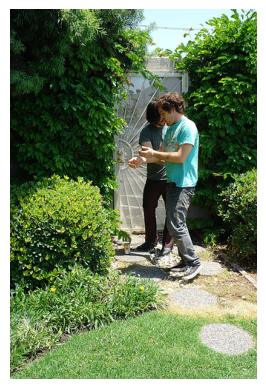

In [5]:
# Display image
import matplotlib.pyplot as plt

plt.imshow(sample["image"])
plt.axis("off")
plt.show()

In [6]:
# Display captions
for caption in sample["caption"]:
    print(caption)

Two young guys with shaggy hair look at their hands while hanging out in the yard.
Two young, White males are outside near many bushes.
Two men in green shirts are standing in a yard.
A man in a blue shirt standing in a garden.
Two friends enjoy time spent together.


### Observation

The dataset contains image-caption pairs where each image is associated with multiple captions. This structure is well suited for supervised image-text matching because the original captions can be treated as positive examples for the corresponding image.

Later in the project, negative examples can be created by pairing an image with captions from other unrelated images.


## Dataset Splits

Although the Hugging Face dataset is loaded under a single `"test"` key, the original Flickr30k split information is stored in the `split` column.

This column separates the data into training, validation, and test subsets. Since these predefined splits are already available, they will be used later for model training and evaluation instead of creating a new random split.


In [9]:
from collections import Counter

split_counts = Counter(dataset["test"]["split"])
split_counts

Counter({'train': 29000, 'val': 1014, 'test': 1000})

In [10]:
import pandas as pd

split_df = pd.DataFrame(
    split_counts.items(),
    columns=["split", "num_images"]
).sort_values("split")

split_df

,split,num_images
1,test,1000
0,train,29000
2,val,1014


### Observation

The dataset contains:

* 29,000 training images
* 1,014 validation images
* 1,000 test images

This is a suitable split for the project because the test set can remain untouched until final model evaluation, while the validation set can be used for model selection and hyperparameter tuning.


## Caption Distribution per Image

Each image in Flickr30k is expected to be associated with multiple human-written captions. Before proceeding with further analysis, it is useful to verify that the dataset contains the expected number of captions per image.

This check helps validate the integrity of the dataset and confirms the assumptions that will later be used when constructing positive image-text pairs for model training.


In [11]:
caption_counts = [len(sample["caption"]) for sample in dataset["test"]]

pd.Series(caption_counts).value_counts().sort_index()

5    31014
Name: count, dtype: int64

### Observation

Every image in the dataset is associated with exactly five captions. This is consistent with the original Flickr30k dataset design and provides multiple positive text descriptions for each image.

Having multiple captions per image is particularly valuable for multimodal learning tasks because it allows the model to learn that different textual descriptions can refer to the same visual content.


In [12]:
pd.Series(caption_counts).describe()

count    31014.0
mean         5.0
std          0.0
min          5.0
25%          5.0
50%          5.0
75%          5.0
max          5.0
dtype: float64

## Visual Inspection of Image-Caption Pairs

Before performing quantitative analysis, it is useful to manually inspect a few randomly selected samples from the dataset.

Visual inspection helps develop intuition about the data and verify that the captions accurately describe the corresponding images. It also provides insight into the diversity of scenes, objects, activities, and writing styles represented in the dataset.

Since each image is associated with five different captions, this inspection allows us to observe how multiple annotators describe the same visual content using different words and levels of detail.


In [27]:
import importlib
import src.data.utils as reporting
importlib.reload(reporting)
import src.config as reporting_33
importlib.reload(reporting_33)

<module 'src.config' from '/Users/maksymstefanko/ML/ML-love/flickr30k-multimodal-retrieval/src/config.py'>

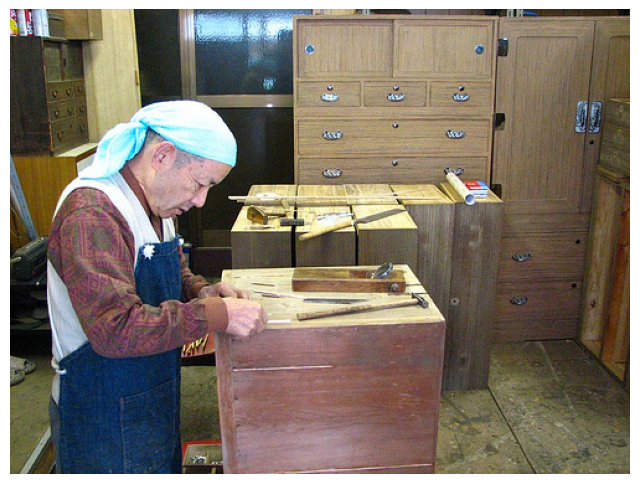

Index: 20952
Image ID: 20952
Filename: 463988257.jpg

1. A man in a blue apron and blue headscarf stands in front of a wooden counter with a hammer on it.
2. An old man wearing a bandanna and a denim apron looks at a cabinet in a workshop.
3. Old man wearing a blue bandanna and building furniture.
4. An old carpenter constructs a chest.
5. An old man working on a craft.


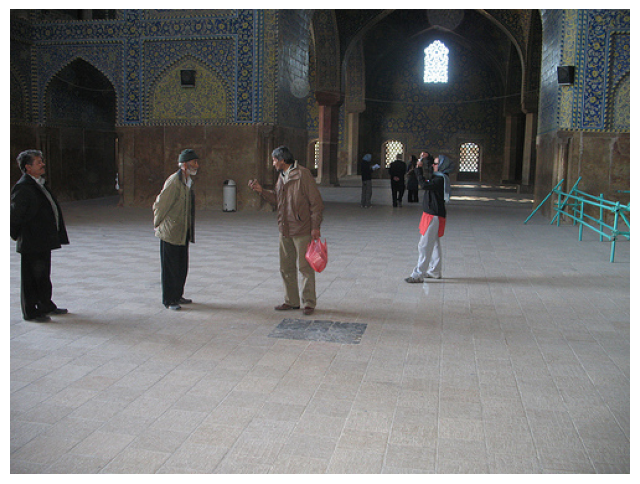

Index: 3648
Image ID: 3648
Filename: 2152057198.jpg

1. A man in a brown jacket holding a red bag is speaking to another man with a white beard and green cap.
2. A man on a brown coat is talking to a man with black pants and a man in a suit.
3. Two men are having a conversation in a cathedral or mosque.
4. People inside of a building, one is taking a photo.
5. Two elderly men having a conversation.


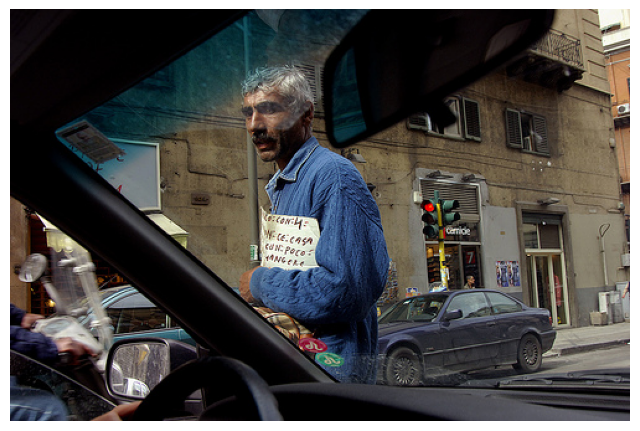

Index: 819
Image ID: 819
Filename: 127875146.jpg

1. A man in a blue sweater stares at the driver of a car on the street.
2. A man holding a sign up at someones windshield.
3. A man is standing on a street holding a sign.
4. A man in a blue sweater walks in traffic.
5. A strange looking guy looking into a car.


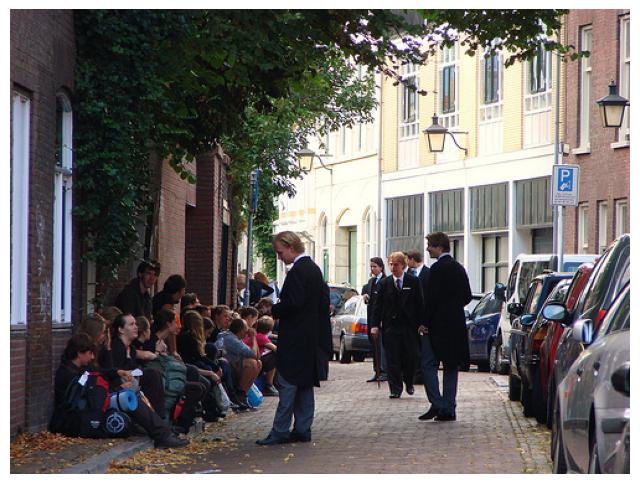

Index: 24299
Image ID: 24299
Filename: 4912928858.jpg

1. A crowd sits along side a building as a man talks to them and another group of men hang out nearby on a sidewalk.
2. People gather in a small alleyway, some fancy, and some in street clothes.
3. A group of men in tuxedos are talking to people sitting on the sidewalk.
4. Many people sit, some stand outside of a large brick building.
5. A group of people are sitting and a man is talking to them.


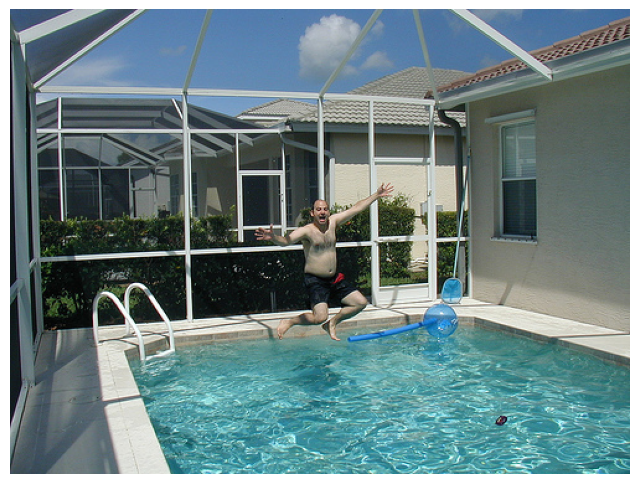

Index: 9012
Image ID: 9012
Filename: 2863501449.jpg

1. A man in black shorts jumping into a small swimming pool that is enclosed in a screened-in porch.
2. A white male in black and red swim trunks is jumping into an indoor pool.
3. Man in black swim trunks jumping in a swimming pool.
4. A man is jumping into a screened-in outdoor pool.
5. An excited man jumps in his pool!


In [29]:
from src.data.utils import show_sample, get_random_indices
from src.config import RANDOM_SEED

sample_indices = get_random_indices(dataset, n=5, seed=RANDOM_SEED)

for idx in sample_indices:
    show_sample(dataset, idx)

### Observation

Visual inspection confirms that the captions generally provide accurate descriptions of the corresponding images. While the five captions associated with each image describe the same scene, they often differ in wording, level of detail, and focus. Different annotators may emphasize objects, actions, appearance, or environmental context.

This variability is particularly valuable for multimodal learning because it encourages models to learn semantic relationships between images and text rather than relying on exact word matching.
